In [ ]:
# Legal Analytics: Auditoria de Improbidade Administrativa (TJRR)

## ⚖️ Sobre o Projeto
Este projeto utiliza técnicas de **Data Science** e **Legal Analytics** para auditar o estoque de processos de Improbidade Administrativa no Tribunal de Justiça de Roraima (TJRR). 

O objetivo é fornecer inteligência de dados para a **Procuradoria Legislativa**, identificando os gargalos processuais e o perfil dos litígios no estado de Roraima.

## 📊 Principais Insights Extraídos
- **Volume:** Análise de 366 processos ativos de improbidade.
- **Geolocalização:** Identificação de que Boa Vista concentra a maior parte do passivo.
- **Conexão Criminal:** X% dos casos de improbidade possuem ação penal associada.
- **Polo Passivo:** Categorização entre agentes públicos (PF) e empresas (PJ).

## 🛠️ Tecnologias Utilizadas
- **Python 3.x**
- **Pandas**: Limpeza e manipulação de metadados processuais.
- **Matplotlib**: Visualização de dados estatísticos.
- **RegEx**: Extração de matérias jurídicas em campos não estruturados.

## 🚀 Relevância Profissional
Este repositório demonstra a aplicação prática de **LegalOps** e **Data Science** no setor público, focado na eficiência da gestão jurídica e no combate à corrupção.

In [1]:
import pandas as pd

# ==========================================
# ETAPA 1: VISÃO GERAL E CARREGAMENTO
# ==========================================
# Usamos o sep=';' e encoding='latin1' por ser o padrão do DataJud
try:
    df = pd.read_csv('TJRR_CPL.csv', sep=';', encoding='latin1')
    print("Arquivo TJRR_CPL carregado com sucesso!")
except:
    print("Erro ao carregar. Verifique se o nome do arquivo está correto.")
    print(df_pendentes['materias'].value_counts().head(30))

# ==========================================
# ETAPA 2: PRÉ-PROCESSAMENTO (Sua lógica da Sprint 1)
# ==========================================

# 2.1 Padronizando colunas para snake_case
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

# 2.2 Tratamento de nulos (Essencial: vimos que o TJRR tem muitos campos vazios)
# Substituímos por 'nao_informado' para não perder a linha na contagem
df['materias'] = df['materias'].fillna('nao_informado')

# 2.3 Removendo duplicados explícitos
df.drop_duplicates(inplace=True)

# ==========================================
# ETAPA 3: TESTE DE HIPÓTESES E INSIGHTS
# ==========================================

# Função para contar processos por Matéria e Município (Adaptada da sua number_tracks)
def analisar_estoque(materia_termo, municipio):
    # Busca parcial: encontra 'Direito Tributário' mesmo que esteja dentro de chaves { }
    filtro = df[
        (df['materias'].str.contains(materia_termo, na=False, case=False)) & 
        (df['municipio'] == municipio)
    ]
    return filtro['processo'].count()

# --- Executando a Análise ---

print("\n--- TOP 10 MATÉRIAS EM ESTOQUE NO TJRR ---")
print(df['materias'].value_counts().head(50))

# Se você achar 'tributario' ou 'fazenda' na lista acima, use aqui:
total_tributario_bv = analisar_estoque('tributario', 'Boa Vista')
total_familia_bv = analisar_estoque('familia', 'Boa Vista')

print("-" * 30)
print(f"Estoque de Processos Tributários (Boa Vista): {total_tributario_bv}")
print(f"Estoque de Processos de Família (Boa Vista): {total_familia_bv}")

# ==========================================
# ETAPA 4: CONCLUSÃO PARA O PORTFÓLIO
# ==========================================
# Aqui você escreve o que os dados provaram, como no projeto da Tripleten

Arquivo TJRR_CPL carregado com sucesso!

--- TOP 10 MATÉRIAS EM ESTOQUE NO TJRR ---
materias
{}                                                                                                                  50823
{seeu}                                                                                                              11912
{acao_penal}                                                                                                         6425
{familia}                                                                                                            5453
{acao_penal, violencia_domestica, violencia_domestica_premio}                                                        1938
{violencia_domestica, medida_protetiva_premio}                                                                       1738
{previdenciario}                                                                                                      859
{infancia_civel, infancia}                           

In [2]:
# ==========================================
# ETAPA 3: TESTE DE HIPÓTESES (VERSÃO CORRIGIDA)
# ==========================================

# 1. Primeiro, vamos ver como os municípios estão escritos para não errar o filtro
print("\n--- Municípios encontrados no arquivo (Top 5) ---")
print(df['municipio'].unique()[:5])

# 2. Função de contagem mais "agressiva" (ignora chaves e maiúsculas)
def analisar_estoque_v2(materia_termo):
    # Procuramos o termo dentro das chaves {}
    filtro_materia = df[df['materias'].str.contains(materia_termo, na=False, case=False)]
    return filtro_materia['processo'].count()

# --- Executando a Nova Análise ---

# Buscando o que apareceu no seu TOP 10
total_familia = analisar_estoque_v2('familia')
total_penal = analisar_estoque_v2('acao_penal')
total_improbidade = analisar_estoque_v2('improbidade')
total_previdenciario = analisar_estoque_v2('previdenciario')

print("-" * 30)
print(f"Total de processos de FAMÍLIA (Estado todo): {total_familia}")
print(f"Total de processos PENAIS (Estado todo): {total_penal}")
print(f"Total de IMPROBIDADE ADM: {total_improbidade}")
print(f"Total de PREVIDENCIÁRIO: {total_previdenciario}")

# Se o total de IMPROBIDADE ou PREVIDENCIÁRIO for maior que zero, 
# você já tem o seu projeto de portfólio jurídico!


--- Municípios encontrados no arquivo (Top 5) ---
['BOA VISTA' 'CARACARAI' 'MUCAJAI' 'RORAINOPOLIS' 'SAO LUIZ']
------------------------------
Total de processos de FAMÍLIA (Estado todo): 5535
Total de processos PENAIS (Estado todo): 9267
Total de IMPROBIDADE ADM: 366
Total de PREVIDENCIÁRIO: 860


In [3]:
# Filtramos apenas os processos de Improbidade
df_improbidade = df[df['materias'].str.contains('improbidade', na=False, case=False)]

# Agora contamos quantos existem em cada município
ranking_improbidade = df_improbidade['municipio'].value_counts()

print("--- RANKING DA IMPROBIDADE POR MUNICÍPIO (TJRR) ---")
print(ranking_improbidade)

# Gerando a conclusão para o seu relatório:
top_1 = ranking_improbidade.index[0]
print(f"\nCONCLUSÃO: O município de {top_1} concentra o maior estoque de ações de improbidade.")


--- RANKING DA IMPROBIDADE POR MUNICÍPIO (TJRR) ---
municipio
BOA VISTA       292
RORAINOPOLIS     20
PACARAIMA        18
CARACARAI        10
SAO LUIZ          9
BONFIM            8
ALTO ALEGRE       7
MUCAJAI           2
Name: count, dtype: int64

CONCLUSÃO: O município de BOA VISTA concentra o maior estoque de ações de improbidade.


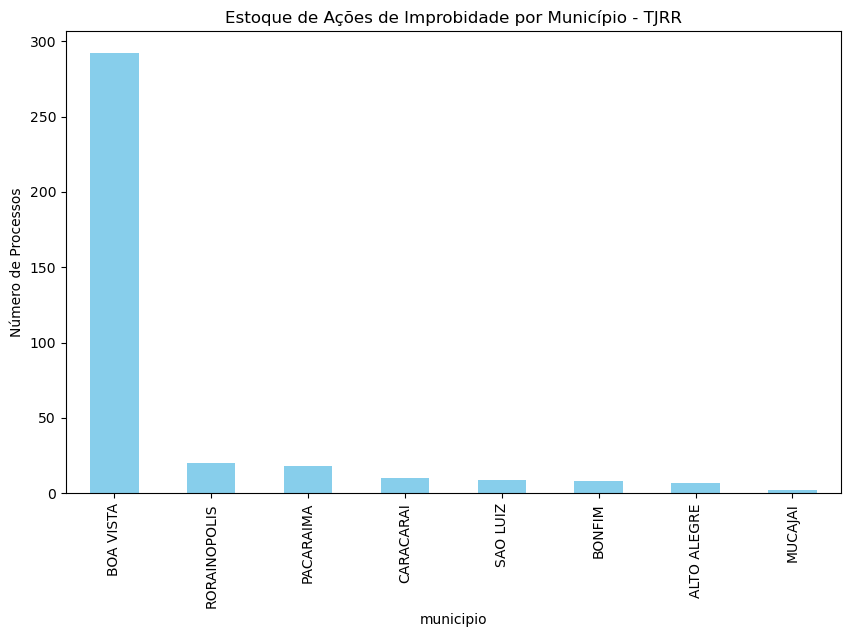

In [4]:
import matplotlib.pyplot as plt

ranking_improbidade.plot(kind='bar', figsize=(10,6), color='skyblue')
plt.title('Estoque de Ações de Improbidade por Município - TJRR')
plt.ylabel('Número de Processos')
plt.show()

In [5]:
print(df_improbidade['materias'].value_counts().head(10))

materias
{acao_penal, improbidade}                                                     209
{improbidade}                                                                 139
{acao_penal, violencia_domestica, violencia_domestica_premio, improbidade}     15
{violencia_domestica, improbidade}                                              2
{acao_penal, , ambientalimprobidade}                                            1
Name: count, dtype: int64


In [6]:
# Ver quem são os maiores réus (Polo Passivo)
print("--- Maiores Réus em Ações de Improbidade ---")
# Limpando espaços e colocando em maiúsculo para agrupar melhor
df_improbidade['polo_passivo_clean'] = df_improbidade['polo_passivo'].str.upper().str.strip()
print(df_improbidade['polo_passivo_clean'].value_counts().head(10))

--- Maiores Réus em Ações de Improbidade ---
polo_passivo_clean
SIGILOSO                                                                  64
{MINISTERIO PUBLICO DO ESTADO DE RORAIMA}                                 32
{ESTADO DE RORAIMA,MINISTERIO PUBLICO DO ESTADO DE RORAIMA}                2
{MADEIREIRA FURTADO LTDA}                                                  2
{ABC EMPREENDIMENTOS LTDA,MC INTERMEDIACOES LTDA}                          1
{MUNICIPIO DE CARACARAI,PREMOL INDUSTRIA COMERCIO E SERVICOS LTDA}         1
{RORAIMA VERDE INDUSTRIA E COMERCIO DE MADEIRAS LTDA}                      1
{LOTUS BUSINESS BV PROMOCAO DE VENDAS LTDA}                                1
{ESTADO DE RORAIMA}                                                        1
{ESTADO DE RORAIMA,BRINGEL MEDICAL DISTRIBUIDORA DE MEDICAMENTOS LTDA}     1
Name: count, dtype: int64


C:\Users\Rodrigo\AppData\Local\Temp\ipykernel_8364\1617716394.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_improbidade['polo_passivo_clean'] = df_improbidade['polo_passivo'].str.upper().str.strip()


In [7]:
import pandas as pd

# 1. Carregamento e Preparação (Mantendo a padronização que já funcionou)
df = pd.read_csv('TJRR_CPL.csv', sep=';', encoding='latin1')
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]
df_improbidade = df[df['materias'].str.contains('improbidade', na=False, case=False)].copy()

print(f"Analisando {len(df_improbidade)} processos de Improbidade...\n")

# --- TÓPICO 1: TEMPO DE TRAMITAÇÃO (PELO ANO) ---
if 'ano' in df_improbidade.columns:
    print("--- 1. VOLUME POR ANO DE ENTRADA (ESTOQUE) ---")
    print(df_improbidade['ano'].value_counts().sort_index())
    print("\n")

# --- TÓPICO 2 E 3: PRINCIPAIS RÉUS E CATEGORIZAÇÃO (PF vs PJ) ---
# Vamos usar o CNPJ para identificar se é Empresa (PJ) ou Pessoa (PF)
def categorizar_reu(row):
    # Se tem CNPJ preenchido, é empresa. Se não, tratamos como Pessoa Física/Outros.
    if pd.notna(row['polo_passivo_-_cnpj']) and str(row['polo_passivo_-_cnpj']).strip() != "":
        return 'Pessoa Jurídica (Empresa/Órgão)'
    return 'Pessoa Física (Agente Público)'

df_improbidade['tipo_reu'] = df_improbidade.apply(categorizar_reu, axis=1)

print("--- 2 e 3. PERFIL DOS RÉUS ---")
print(df_improbidade['tipo_reu'].value_counts())
print("\nTOP 5 RÉUS FREQUENTES:")
print(df_improbidade['polo_passivo'].str.upper().value_counts().head(10))
print("\n")

# --- TÓPICO 4: CONEXÃO CRIMINAL ---
# Verificamos quantas vezes 'acao_penal' aparece na mesma linha de 'improbidade'
casos_criminais = df_improbidade['materias'].str.contains('acao_penal', case=False).sum()
porcentagem_criminal = (casos_criminais / len(df_improbidade)) * 100

print(f"--- 4. CONEXÃO CRIMINAL ---")
print(f"Casos que também são Ações Penais: {casos_criminais}")
print(f"Porcentagem de Conexão Criminal: {porcentagem_criminal:.2f}%")
print("\n")

# --- TÓPICO 5: GRAU DE JURISDIÇÃO E PODER PÚBLICO ---
print("--- 5. INSTÂNCIA E AUTORES ---")
print("Distribuição por Grau (1º vs 2º Instância):")
print(df_improbidade['grau'].value_counts())

print("\nPrincipais Autores (Polo Ativo):")
print(df_improbidade['polo_ativo'].str.upper().value_counts().head(3))

Analisando 366 processos de Improbidade...

--- 1. VOLUME POR ANO DE ENTRADA (ESTOQUE) ---
ano
2026    366
Name: count, dtype: int64


--- 2 e 3. PERFIL DOS RÉUS ---
tipo_reu
Pessoa Física (Agente Público)     232
Pessoa Jurídica (Empresa/Órgão)    134
Name: count, dtype: int64

TOP 5 RÉUS FREQUENTES:
polo_passivo
SIGILOSO                                                                  64
{MINISTERIO PUBLICO DO ESTADO DE RORAIMA}                                 32
{ESTADO DE RORAIMA,MINISTERIO PUBLICO DO ESTADO DE RORAIMA}                2
{MADEIREIRA FURTADO LTDA}                                                  2
{ABC EMPREENDIMENTOS LTDA,MC INTERMEDIACOES LTDA}                          1
{MUNICIPIO DE CARACARAI,PREMOL INDUSTRIA COMERCIO E SERVICOS LTDA}         1
{RORAIMA VERDE INDUSTRIA E COMERCIO DE MADEIRAS LTDA}                      1
{LOTUS BUSINESS BV PROMOCAO DE VENDAS LTDA}                                1
{ESTADO DE RORAIMA}                                                 